In [57]:
from pathlib import Path

import pandas as pd
from acteval.describe.frequency import frequency_plots, plot_agg_acts
from acteval.describe.times import (
    joint_time_distributions_plot,
    times_distributions_plot,
)
from acteval.describe.transitions import _probs_plot, sequence_prob_plot
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

In [ ]:
cmaps = {
    "home": (0.55, 0.71, 0.82),  # #8CB6D1 steel blue
    "work": (0.88, 0.36, 0.32),  # #E15C52 red
    "education": (0.96, 0.78, 0.26),  # #F5C742 golden yellow
    "shop": (0.61, 0.49, 0.78),  # #9C7DC7 purple
    "visit": (0.94, 0.53, 0.23),  # #F0873B amber
    "escort": (0.29, 0.75, 0.73),  # #4ABFBA teal
    "medical": (0.94, 0.53, 0.60),  # #F0879A rose
    "travel": (0.62, 0.62, 0.62),  # #9E9E9E mid grey
    "other": (0.71, 0.80, 0.48),  # #B5CC7A sage green
}

batch_paths = {
    "Compositional": Path("../logs/actvae/compositional"),
    # "MDCEV": Path("../logs/actvae/mdcev"),
    # "ActVAE": Path("../logs/actvae/cpvae"),
    # "Disc RNN": Path("../logs/TRB/discrim"),
    "ActVAE-Cond": Path("../logs/actvae/conditional"),
    "ActVAE-Gen": Path("../logs/actvae/vae"),
    "ActVAE": Path("../logs/actvae/cpvae"),
    # "LLM": Path("../logs/actvae/llm"),
    # "LLM-ft": Path("../logs/actvae/llm_ft"),
}

# find data
target_schedules = pd.read_csv("~/Data/foundata/out/nts/2023/activities.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

target_attributes = pd.read_csv(
    "~/Data/foundata/out/nts/2023/attributes_binned.csv"
)


def latest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    if not versions:
        return path.name, path
    return path.name, versions[-1]


def iter_models(path: Path):
    for dir in path.iterdir():

        if dir.is_dir():

            yield latest(dir)


def find_nth(path: Path, n=0):

    ranks = (
        pd.read_csv(path / "eval" / "domains" / "distances.csv")
        .drop(columns=["domain", "observed", "mean", "std"], errors="ignore")
        .rank(axis=1, method="min")
        .sum(axis=0)
    )
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def best_quality(path: Path, n=0):

    data = pd.read_csv(path / "eval" / "domains" / "distances.csv")
    data = data[data.domain == "sample quality"].drop(
        columns=["domain", "observed", "mean", "std"], errors="ignore"
    )
    ranks = data.rank(axis=1, method="min").sum(axis=0)
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def load_attributes(path: Path, default=None):
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


def split_on(schedules, attributes, by="work_status"):
    splits = attributes.groupby(by)
    return {
        k: schedules.loc[schedules.pid.isin(list(v.pid))] for k, v in splits
    }

/tmp/ipykernel_41034/2538864600.py:42: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  target_attributes = pd.read_csv(


In [3]:
schedules = {
    n: pd.read_csv(next(best_quality(p, 0))[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}
attributes = {
    n: load_attributes(next(best_quality(p, 0))[1], default=target_attributes)
    for n, p in batch_paths.items()
}

Loading synthetic attributes from ../logs/actvae/compositional/seed_11111
Loading synthetic attributes from ../logs/actvae/conditional/conditional_nrun0/version_0
Loading synthetic attributes from ../logs/actvae/vae/vae_nrun0/version_0
Loading synthetic attributes from ../logs/actvae/cpvae/cpvae-add_nrun0/version_0


In [5]:
def build_distance_tables(batch_paths):
    distances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / "eval" / "domains" / "distances.csv"
        ).set_index("domain")

        columns = list(
            set(distances.columns) - set(["domain", "observed", "mean", "std"])
        )
        distances_combined[(name, "EMD")] = distances[columns].mean(axis=1)
        distances_combined[(name, "var")] = distances[columns].var(axis=1)

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    # distances_combined = distances_combined.set_index(
    #     pd.MultiIndex.from_tuples(distances_combined.index)
    # )

    return distances_combined


order = ["participations", "transitions", "timing", "feasibility", "creativity"]
df = build_distance_tables(batch_paths)
print(df.loc[order].to_latex(float_format="{:.3f}".format))
df

\begin{tabular}{lrrrrrrrr}
\toprule
 & \multicolumn{2}{r}{Compositional} & \multicolumn{2}{r}{ActVAE-Cond} & \multicolumn{2}{r}{ActVAE-Gen} & \multicolumn{2}{r}{ActVAE} \\
 & EMD & var & EMD & var & EMD & var & EMD & var \\
domain &  &  &  &  &  &  &  &  \\
\midrule
participations & 0.084 & 0.000 & 0.402 & 0.000 & 0.117 & 0.000 & 0.083 & 0.000 \\
transitions & 0.004 & 0.000 & 0.020 & 0.000 & 0.007 & 0.000 & 0.004 & 0.000 \\
timing & 0.080 & 0.000 & 0.200 & 0.000 & 0.057 & 0.000 & 0.047 & 0.000 \\
feasibility & 0.000 & 0.000 & 0.000 & 0.000 & 0.015 & 0.000 & 0.015 & 0.000 \\
creativity & 0.060 & 0.000 & 0.264 & 0.000 & 0.030 & 0.000 & 0.032 & 0.000 \\
\bottomrule
\end{tabular}



Compositional               ActVAE-Cond                \
                         EMD           var         EMD           var   
domain                                                                 
creativity          0.059834  5.026846e-08    0.263887  2.661078e-05   
feasibility         0.000000  0.000000e+00    0.000113  6.437238e-08   
participations      0.083565  3.998159e-06    0.402156  9.148612e-06   
timing              0.079822  1.260796e-08    0.199801  1.141230e-04   
transitions         0.003753  3.281219e-09    0.020392  3.442013e-07   

               ActVAE-Gen                  ActVAE                
                      EMD           var       EMD           var  
domain                                                           
creativity       0.030135  5.550655e-07  0.031776  1.936154e-07  
feasibility      0.015047  7.636629e-05  0.014670  2.520793e-06  
participations   0.117443  6.505279e-06  0.083007  1.567493e-05  
timing           0.056512  3.933448e-06  0.046785  2.177686e-06  
transitions      0.006664  1.228678e-07  0.003833  4.485888e-07

In [6]:
def group_tables(batch_paths):
    distances_combined = pd.DataFrame()
    descriptions_combined = pd.DataFrame()
    variances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / "eval" / "groups" / "distances.csv"
        ).set_index(["domain", "feature"])
        descriptions = pd.read_csv(
            path / "eval" / "groups" / "descriptions.csv"
        ).set_index(["domain", "feature"])

        columns = set(distances.columns)
        columns = list(
            columns - set(["observed", "unit", "mean", "std", "sub_pop"])
        )

        print(name, columns)

        distances_combined[(name, "mean")] = distances[columns].mean(axis=1)
        distances_combined[(name, "var")] = distances[columns].var(axis=1)
        variances_combined[(name, "std")] = distances[columns].std(axis=1)
        descriptions_combined[(name, "mean")] = descriptions[columns].mean(
            axis=1
        )

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )
    variances_combined.columns = pd.MultiIndex.from_tuples(
        variances_combined.columns
    )
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return (
        distances_combined.loc[index],
        variances_combined,
        descriptions_combined.loc[index],
    )


dist_dist, dist_std, dist_desc = group_tables(batch_paths)
print(dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))

Compositional ['seed_44444', 'seed_11111', 'seed_22222', 'seed_33333', 'seed_55555']
ActVAE-Cond ['conditional_nrun1', 'conditional_nrun3', 'conditional_nrun2', 'conditional_nrun0', 'conditional_nrun4']
ActVAE-Gen ['vae_nrun3', 'vae_nrun2', 'vae_nrun4', 'vae_nrun1', 'vae_nrun0']
ActVAE ['cpvae-add_nrun0', 'cpvae-add_nrun2', 'cpvae-add_nrun3', 'cpvae-add_nrun4', 'cpvae-add_nrun1']
\begin{tabular}{lrrrrrrrr}
\toprule
 & \multicolumn{2}{r}{Compositional} & \multicolumn{2}{r}{ActVAE-Cond} & \multicolumn{2}{r}{ActVAE-Gen} & \multicolumn{2}{r}{ActVAE} \\
 & mean & var & mean & var & mean & var & mean & var \\
feature &  &  &  &  &  &  &  &  \\
\midrule
lengths & 0.199 & 0.000 & 0.997 & 0.000 & 0.274 & 0.000 & 0.206 & 0.000 \\
pair participation rate & 0.008 & 0.000 & 0.018 & 0.000 & 0.006 & 0.000 & 0.004 & 0.000 \\
participation rate & 0.044 & 0.000 & 0.191 & 0.000 & 0.073 & 0.000 & 0.039 & 0.000 \\
2-gram & 0.007 & 0.000 & 0.049 & 0.000 & 0.015 & 0.000 & 0.008 & 0.000 \\
3-gram & 0.002 & 0.

In [7]:
def build_all_description_tables(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(
            path / "eval" / "features" / "descriptions.csv"
        ).set_index(["domain", "feature", "segment"])
        distances = pd.read_csv(
            path / "eval" / "features" / "distances.csv"
        ).set_index(["domain", "feature", "segment"])
        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(
                [
                    "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                ]
            )
            - weights
        )
        descriptions_combined[name, "mean"] = descriptions[columns].mean(axis=1)
        # descriptions_combined[name, "var"] = descriptions[columns].var(axis=1)
        descriptions_combined[name, "EMD"] = distances[columns].mean(axis=1)

    descriptions_combined["Observed", ""] = descriptions["observed"]
    descriptions_combined["Description", ""] = descriptions["unit"]
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )
    descriptions_combined = descriptions_combined.groupby(
        ["domain", "feature"], group_keys=False
    ).apply(
        lambda x: x.sort_values([("Observed", "")], ascending=False).head(20)
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order = [("Observed", "")] + order

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return descriptions_combined.loc[index, order]


table = build_all_description_tables(batch_paths)

p = table.loc["participations"]
for name in ["lengths", "participation rate", "pair participation rate"]:
    print(name)
    print(p.loc[name].to_latex(float_format="{:.3f}".format))
    print()

table.loc["participations"]

lengths
\begin{tabular}{lrrrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Compositional} & \multicolumn{2}{r}{ActVAE-Cond} & \multicolumn{2}{r}{ActVAE-Gen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  &  &  \\
\midrule
sequence lengths & 3.931 & 3.834 & 0.199 & 3.012 & 0.997 & 3.863 & 0.274 & 3.887 & 0.206 & length. \\
\bottomrule
\end{tabular}


participation rate
\begin{tabular}{lrrrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Compositional} & \multicolumn{2}{r}{ActVAE-Cond} & \multicolumn{2}{r}{ActVAE-Gen} & \multicolumn{2}{r}{ActVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  &  &  \\
\midrule
home & 2.326 & 2.324 & 0.075 & 2.006 & 0.372 & 2.273 & 0.128 & 2.291 & 0.105 & av. rate \\
other & 0.531 & 0.498 & 0.065 & 0.498 & 0.216 & 0.463 & 0.100 & 0.535 & 0.050 & av. rate \\
shop & 0.298 & 0.278 & 0.030 & 0.027 &

Observed Compositional            \
                                                               mean       EMD   
feature                 segment                                                 
lengths                 sequence lengths     3.930729      3.833958  0.199158   
pair participation rate home+home            1.055170      1.052037  0.033885   
                        other+other          0.086897      0.058112  0.030486   
                        home+other           0.084394      0.058112  0.027970   
                        escort+escort        0.076145      0.029193  0.047569   
                        escort+home          0.073060      0.029193  0.044485   
                        shop+shop            0.034124      0.020718  0.013986   
                        home+shop            0.033472      0.020718  0.013341   
                        visit+visit          0.013572      0.002704  0.010955   
                        home+visit           0.013343      0.002704  0.010723   
                        home+work            0.010311      0.000000  0.010306   
                        work+work            0.010311      0.000000  0.010306   
                        escort+other         0.004759      0.002069  0.002770   
                        other+shop           0.002820      0.001121  0.001748   
                        escort+shop          0.002203      0.000575  0.001637   
                        other+visit          0.001833      0.000095  0.001765   
                        home+medical         0.001622      0.000469  0.001167   
                        medical+medical      0.001622      0.000469  0.001167   
                        education+education  0.001128      0.000000  0.001116   
                        education+home       0.001128      0.000000  0.001116   
                        shop+visit           0.000969      0.000063  0.000910   
participation rate      home                 2.325642      2.323886  0.075078   
                        other                0.530617      0.497517  0.065318   
                        shop                 0.297864      0.278028  0.029947   
                        escort               0.257676      0.254113  0.124533   
                        work                 0.254644      0.246176  0.019829   
                        visit                0.129799      0.106757  0.026193   
                        education            0.091162      0.090120  0.006730   
                        medical              0.043325      0.041610  0.004012   

                                            ActVAE-Cond           ActVAE-Gen  \
                                                   mean       EMD       mean   
feature                 segment                                                
lengths                 sequence lengths       3.012324  0.997125   3.862901   
pair participation rate home+home              1.000208  0.081328   1.046287   
                        other+other            0.000427  0.086647   0.068453   
                        home+other             0.000427  0.084127   0.066634   
                        escort+escort          0.005595  0.071690   0.049657   
                        escort+home            0.005595  0.068569   0.048324   
                        shop+shop              0.000000  0.034873   0.034774   
                        home+shop              0.000000  0.034211   0.033667   
                        visit+visit            0.000000  0.013572   0.010259   
                        home+visit             0.000000  0.013343   0.010001   
                        home+work              0.000000  0.010400   0.010509   
                        work+work              0.000000  0.010400   0.010509   
                        escort+other           0.000000  0.004797   0.002588   
                        other+shop             0.000000  0.002882   0.001826   
                        escort+shop            0.000000  0.002247   0.001361   
            

In [8]:
def build_labels_table(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        label_distances = pd.read_csv(
            path / "eval" / "domains_by_attribute" / "distances.csv"
        ).set_index(["domain", "label"])

        columns = set(label_distances.columns)
        # unit = label_distances["unit"].groupby(["domain", "label"]).first()

        columns = list(
            columns
            - set(
                [
                    # "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                    "cat",
                    "label",
                    "domain",
                    "feature",
                    "segment",
                ]
            )
        )
        label_distances = (
            label_distances[columns].groupby(["domain", "label"]).mean()
        )

        descriptions_combined[name, "EMD"] = label_distances.mean(axis=1)
        descriptions_combined[name, "var"] = label_distances.var(axis=1)

    # descriptions_combined["Description", ""] = unit
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    order = list(descriptions_combined.columns)

    index = ["participations", "transitions", "timing"]

    return descriptions_combined.loc[index, order]


table = build_labels_table(batch_paths)
print(table.to_latex(float_format="{:.3f}".format))


table

\begin{tabular}{llrrrrrrrr}
\toprule
 &  & \multicolumn{2}{r}{Compositional} & \multicolumn{2}{r}{ActVAE-Cond} & \multicolumn{2}{r}{ActVAE-Gen} & \multicolumn{2}{r}{ActVAE} \\
 &  & EMD & var & EMD & var & EMD & var & EMD & var \\
domain & label &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{8}{*}{participations} & access_egress_distance & 0.046 & 0.000 & 0.370 & 0.000 & 0.088 & 0.000 & 0.045 & 0.000 \\
 & age & 0.047 & 0.000 & 0.377 & 0.000 & 0.109 & 0.000 & 0.052 & 0.000 \\
 & day & 0.045 & 0.000 & 0.372 & 0.000 & 0.066 & 0.000 & 0.043 & 0.000 \\
 & employment & 0.047 & 0.000 & 0.379 & 0.000 & 0.103 & 0.000 & 0.053 & 0.000 \\
 & hh_income & 0.045 & 0.000 & 0.371 & 0.000 & 0.064 & 0.000 & 0.040 & 0.000 \\
 & hh_zone & 0.045 & 0.000 & 0.370 & 0.000 & 0.068 & 0.000 & 0.040 & 0.000 \\
 & sex & 0.045 & 0.000 & 0.370 & 0.000 & 0.060 & 0.000 & 0.040 & 0.000 \\
 & vehicles & 0.349 & 0.000 & 0.609 & 0.000 & 0.382 & 0.000 & 0.349 & 0.000 \\
\cline{1-10}
\multirow[t]{8}{*}{transitions} & acce

Compositional               ActVAE-Cond  \
                                                EMD           var         EMD   
domain         label                                                            
participations access_egress_distance      0.045854  3.177126e-06    0.370055   
               age                         0.047406  5.186829e-06    0.376730   
               day                         0.045260  4.397355e-06    0.372402   
               employment                  0.046661  4.460148e-06    0.378981   
               hh_income                   0.044817  4.792962e-06    0.370581   
               hh_zone                     0.044596  4.897223e-06    0.369870   
               sex                         0.044501  4.673413e-06    0.369956   
               vehicles                    0.349396  2.038125e-06    0.609031   
transitions    access_egress_distance      0.003366  2.841193e-09    0.019775   
               age                         0.003464  4.907644e-09    0.020712   
               day                         0.003310  2.786768e-09    0.020202   
               employment                  0.003315  5.639886e-09    0.021347   
               hh_income                   0.003250  3.388612e-09    0.019931   
               hh_zone                     0.003157  3.529729e-09    0.019801   
               sex                         0.003130  2.853468e-09    0.019833   
               vehicles                    0.007027  3.307570e-09    0.021563   
timing         access_egress_distance      0.054299  8.973433e-09    0.173686   
               age                         0.056071  3.878788e-08    0.191603   
               day                         0.054612  1.105850e-08    0.172217   
               employment                  0.054917  1.780349e-08    0.188280   
               hh_income                   0.053864  1.895159e-08    0.167857   
               hh_zone                     0.053480  1.405538e-08    0.170133   
               sex                         0.053364  1.708467e-08    0.168617   
               vehicles                    0.257986  3.824813e-08    0.366031   

                                                    ActVAE-Gen                \
                                                var        EMD           var   
domain         label                                                           
participations access_egress_distance  1.196578e-05   0.087551  7.162444e-06   
               age                     8.462968e-06   0.109198  4.255505e-06   
               day                     5.225668e-06   0.066029  1.792339e-05   
               employment              1.107078e-05   0.103012  1.565031e-05   
               hh_income               1.126835e-05   0.064103  1.579833e-05   
               hh_zone                 1.208055e-05   0.067974  1.968518e-05   
               sex                     1.262730e-05   0.060013  1.848520e-05   
               vehicles                7.034989e-06   0.381686  8.056364e-06   
transitions    access_egress_distance  5.656443e-07   0.005451  9.886000e-08   
               age                     2.688354e-08   0.010119  1.239464e-07   
               day                     3.992925e-07   0.005442  1.053977e-07   
               employment              1.161355e-07   0.010445  1.121894e-07   
               hh_income               6.766761e-07   0.004872  1.392709e-07   
               hh_zone                 7.392230e-07   0.004452  1.910719e-07   
               sex                     8.416556e-07   0.004363  1.540916e-07   
               vehicles                3.398934e-07   0.008170  9.874223e-08   
timing         access_egress_distance  1.324358e-04   0.027464  4.191002e-06   
               age                     2.848773e-04   0.047280  3.365025e-06   
               day                     1.251075e-04   0.027404  4.712620e-06   
               employment              3.098071e-04   0.044128  3.013970e-06   
          

In [9]:
# def build_all_description_tables_subs_fixed(batch_paths, on="work_status"):
#     descriptions_combined = pd.DataFrame()

#     for name, path in batch_paths.items():
#         label_descriptions = pd.read_csv(
#             path / "eval" / "features_by_attribute" / "descriptions.csv"
#         )
#         label_distances = pd.read_csv(
#             path / "eval" / "features_by_category" / "distances.csv"
#         )
#         descriptions = pd.read_csv(
#             path / "eval" / "features_by_category" / "descriptions.csv"
#         )

#         columns = set(label_descriptions.columns)
#         columns = list(
#             columns
#             - set(
#                 [
#                     "label",
#                     "cat",
#                     "description",
#                     "mean",
#                     "std",
#                     "feature count",
#                     "unit",
#                 ]
#             )
#         )

#         distances = (
#             label_distances[columns]
#             .loc[label_distances.label == on]
#             .set_index(["domain", "feature", "segment"])
#             .groupby(["domain", "feature", "segment"])
#             .mean()
#         ).reset_index()
#         descriptions["label"] = on
#         distances["label"] = on
#         descriptions["cat"] = "combined"
#         distances["cat"] = "combined"

#         columns = set(distances.columns)
#         weights = set([c for c in columns if "weight" in c])
#         columns = list(
#             columns
#             - set(
#                 [
#                     "observed",
#                     "description",
#                     "mean",
#                     "std",
#                     "feature count",
#                     "unit",
#                 ]
#             )
#             - weights
#         )
#         distances = distances[columns]

#         label_descriptions = pd.concat((label_descriptions, descriptions))
#         label_distances = pd.concat((label_distances, distances))

#         label_descriptions = (
#             label_descriptions.loc[label_descriptions.label == on]
#             .drop("label", axis=1)
#             .set_index(["domain", "feature", "segment", "cat"])
#         )
#         label_distances = (
#             label_distances.loc[label_distances.label == on]
#             .drop("label", axis=1)
#             .set_index(["domain", "feature", "segment", "cat"])
#         )

#         columns = set(label_descriptions.columns)
#         weights = set([c for c in columns if "weight" in c])
#         columns = list(
#             columns
#             - set(
#                 [
#                     "observed",
#                     "description",
#                     "mean",
#                     "std",
#                     "feature count",
#                     "unit",
#                 ]
#             )
#             - weights
#         )

#         observed = label_descriptions["observed"]
#         unit = label_descriptions["unit"]

#         label_descriptions = label_descriptions[columns]
#         label_distances = label_distances[columns]

#         descriptions_combined[name, "mean"] = label_descriptions.mean(axis=1)
#         descriptions_combined[name, "EMD"] = label_distances.mean(axis=1)

#     descriptions_combined["Observed", ""] = observed
#     descriptions_combined["Description", ""] = unit
#     descriptions_combined.columns = pd.MultiIndex.from_tuples(
#         descriptions_combined.columns
#     )
#     descriptions_combined["maxi"] = descriptions_combined.Observed.groupby(
#         ["domain", "feature", "segment"], group_keys=False
#     ).transform("max")
#     descriptions_combined = descriptions_combined.sort_values(
#         ["maxi"], ascending=False
#     ).drop(columns=["maxi"])

#     descriptions_combined = descriptions_combined.groupby(
#         ["domain", "feature"], group_keys=False
#     ).apply(lambda x: x.head(1000))

#     order = list(descriptions_combined.columns)
#     order.pop(order.index(("Observed", "")))
#     order = [("Observed", "")] + order

#     index = [
#         "participations",
#         "transitions",
#         "timing",
#         "feasibility",
#         "creativity",
#     ]

#     return descriptions_combined.loc[index, order]


# table = build_all_description_tables_subs_fixed(batch_paths)

# p = table.loc["participations"]
# for name in ["lengths", "participation rate"]:
#     print(name)
#     pp = p.loc[name]
#     pp.loc[:, "Description"] = "rate"
#     print(pp.to_latex(float_format="{:.3f}".format))
#     print()

In [10]:
# table = build_all_description_tables_subs_fixed(batch_paths, on="gender")
# t = table.loc["transitions"]
# acts = [
#     "home>other",
#     "home>work",
#     "home>education",
#     "home>shop",
#     "home>visit",
#     "home>escort",
#     "home>medical",
# ]
# data = []
# for act in acts:
#     tt = t.loc["2-gram"]
#     tt.loc[:, "Description"] = "rate"
#     tt = tt.loc[([act]),]
#     data.append(tt)
# data = pd.concat(data)
# data = data.sort_index(ascending=False)
# print(data.to_latex(float_format="{:.3f}".format))
# data

In [11]:
# table = build_all_description_tables_subs_fixed(batch_paths, on="car_access")
# t = table.loc["timing"]
# acts = ["work0", "education0", "shop0", "home0", "visit0", "home1"]
# data = []
# for act in acts:
#     tt = t.loc["start times"]
#     tt.loc[:, "Description"] = "days"
#     tt = tt.loc[([act]),]
#     data.append(tt)
# data = pd.concat(data)
# data = data.sort_index(ascending=False)
# print(data.to_latex(float_format="{:.3f}".format))

# data = []
# for act in acts:
#     tt = t.loc["durations"]
#     tt.loc[:, "Description"] = "days"
#     tt = tt.loc[([act]),]
#     data.append(tt)
# data = pd.concat(data)
# data = data.sort_index(ascending=False)
# print(data.to_latex(float_format="{:.3f}".format))

In [ ]:
from acteval.describe.times import durations_by_act, start_times_by_act
from acteval.describe.utils import _to_population
from matplotlib.figure import Axes, Figure


def time_plot(schedules, **kwargs) -> Figure:
    names = list(schedules.keys())
    pop = schedules[names[0]]
    acts = pop.act.value_counts().sort_values(ascending=False).index.tolist()
    acts.remove("home")
    n_acts = len(acts)
    rows = len(names)

    cmaps = kwargs.pop("cmaps", {})

    fig, axs = plt.subplots(
        rows,
        n_acts,
        figsize=kwargs.pop("figsize", (12, 5)),
        sharex=False,
        sharey=False,
    )

    for i, (name, y) in enumerate(schedules.items()):

        axs[i, 0].set_ylabel(name, fontsize=10, rotation=90)

        _joint_time_plot(_to_population(y), axs[i], acts, cmaps=cmaps)

    for ax in axs[-1]:
        ax.set_xlabel("Start times", fontsize=8)
        ax.set_xticks(
            [240, 480, 720, 960, 1200, 1440],
            labels=["04:00", "08:00", "12:00", "16:00", "20:00", "24:00"],
            rotation=90,
            fontsize=8,
        )

    for ax, title in zip(axs[:, 0], names):
        ax.text(
            -1,
            0.5,
            title,
            transform=ax.transAxes,
            fontsize=10,
            rotation=90,
            va="center",
            ha="center",
        )

    for ax, act in zip(axs[0], acts):
        ax.set_title(act.title(), fontsize=9)

    return fig


def _joint_time_plot(
    population,
    axs: Axes,
    acts: list[str],
    cmaps: dict,
    xmin: int = 240,
    xmax: int = 1441,
    ymin: int = 0,
    ymax: int = 960,
    xstep: int = 60,
    ystep: int = 60,
):
    pop = _to_population(population)
    start_feats = start_times_by_act(pop, bin_size=None)
    dur_feats = durations_by_act(pop, bin_size=None)

    start_bins = list(range(xmin, xmax, xstep))
    duration_bins = list(range(ymin, ymax, ystep))

    for i, act in enumerate(acts):
        cmap = cmaps.get(act)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
        if act not in start_feats.data:
            continue
        act_starts = start_feats.data[act][0]
        act_durations = dur_feats.data[act][0]
        axs[i].hist2d(
            x=act_starts,
            y=act_durations,
            bins=(start_bins, duration_bins),
            cmap=cmap,
            cmin=1,
        )
    axs[0].set_ylabel("Durations", fontsize=8)
    axs[0].set_yticks(
        [0, 240, 480, 720, 960],
        labels=["00:00", "04:00", "08:00", "12:00", "16:00"],
        fontsize=8,
    )

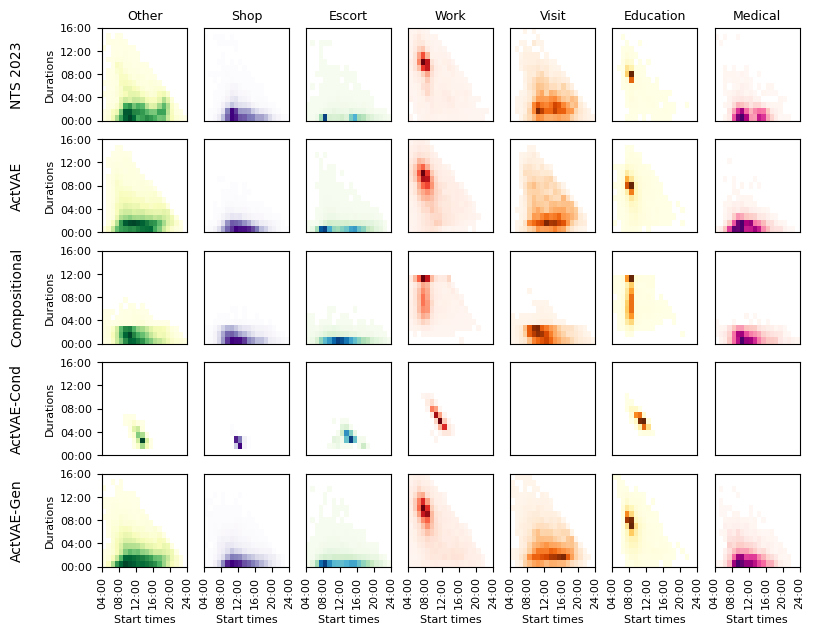

In [120]:
selected = {
    "NTS 2023": target_schedules,
    "ActVAE": schedules["ActVAE"],
    "Compositional": schedules["Compositional"],
    "ActVAE-Cond": schedules["ActVAE-Cond"],
    "ActVAE-Gen": schedules["ActVAE-Gen"],
}

cmaps = {
    "work": "Reds",
    "education": "YlOrBr",
    "shop": "Purples",
    "visit": "Oranges",
    "escort": "GnBu",
    "medical": "RdPu",
    "travel": "Greys",
    "other": "YlGn",
}

fig = time_plot(
    selected, figsize=(9, 7), observed_title="NTS 2023", cmaps=cmaps
)
plt.subplots_adjust(wspace=0.2, hspace=0.2)

In [128]:
import random

from pam.core import Household, Person
from pam.plot.plans import plot_household
from pandas import DataFrame

from caveat.data.utils import trace_to_pam


def stretch(schedules):
    return schedules.groupby(schedules.pid).apply(stretcher)


def stretcher(schedule):
    duration = schedule.duration.sum()
    if duration != 1440:
        a = 1440 / duration
        schedule.duration = (schedule.duration * a).astype(int)
        accumulated = list(schedule.duration.cumsum())
        schedule.start = [0] + accumulated[:-1]
        schedule.end = accumulated
    return schedule


def trim(schedules):
    schedules[schedules.end > 1440] = 1440
    schedules[schedules.start > 1440] = 1440
    schedules.duration = schedules.end - schedules.start
    schedules = schedules[schedules.duration > 0]
    return schedules


def pad(schedules):
    return (
        schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
    )


def padder(schedule):
    if schedule.end.iloc[-1] < 1440 and schedule.act.iloc[-1] != "home":
        pid = schedule.pid.iloc[0]
        schedule = pd.concat(
            [
                schedule,
                DataFrame(
                    {
                        "pid": pid,
                        "start": schedule.end.iloc[-1],
                        "end": 1440,
                        "duration": 1440 - schedule.end.iloc[-1],
                        "act": "home",
                    },
                    index=[0],
                ),
            ]
        )
    elif schedule.end.iloc[-1] < 1440:
        schedule.end.iloc[-1] = 1440
        schedule.duration.iloc[-1] = 1440 - schedule.start.iloc[-1]
    return schedule


def plot_schedules(schedules, **kwargs):
    cmap = kwargs.pop("cmap")
    cmap = {n.title(): c for n, c in cmap.items()}
    if "duration" not in schedules.columns:
        schedules["duration"] = schedules.end - schedules.start
    hh = Household("")
    pids = schedules.pid
    selected = random.sample(list(pids), 8)
    for i, pid in enumerate(selected):
        person = Person(pid)
        plan = schedules[schedules.pid == pid]
        plan = trim(stretch(pad(plan)))[["act", "start", "end", "duration"]]
        mapping = {a: a for a in plan.act}

        trace = [
            (row.act, row.start, row.end, row.duration)
            for i, row in plan.iterrows()
        ]
        plan = trace_to_pam(trace, mapping)

        person = Person(i)
        person.plan = plan
        hh.add(person)

    plot_household(hh, cmap=cmap, width=25)

/tmp/ipykernel_41034/2729459132.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_41034/2729459132.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_41034/2729459132.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This beha

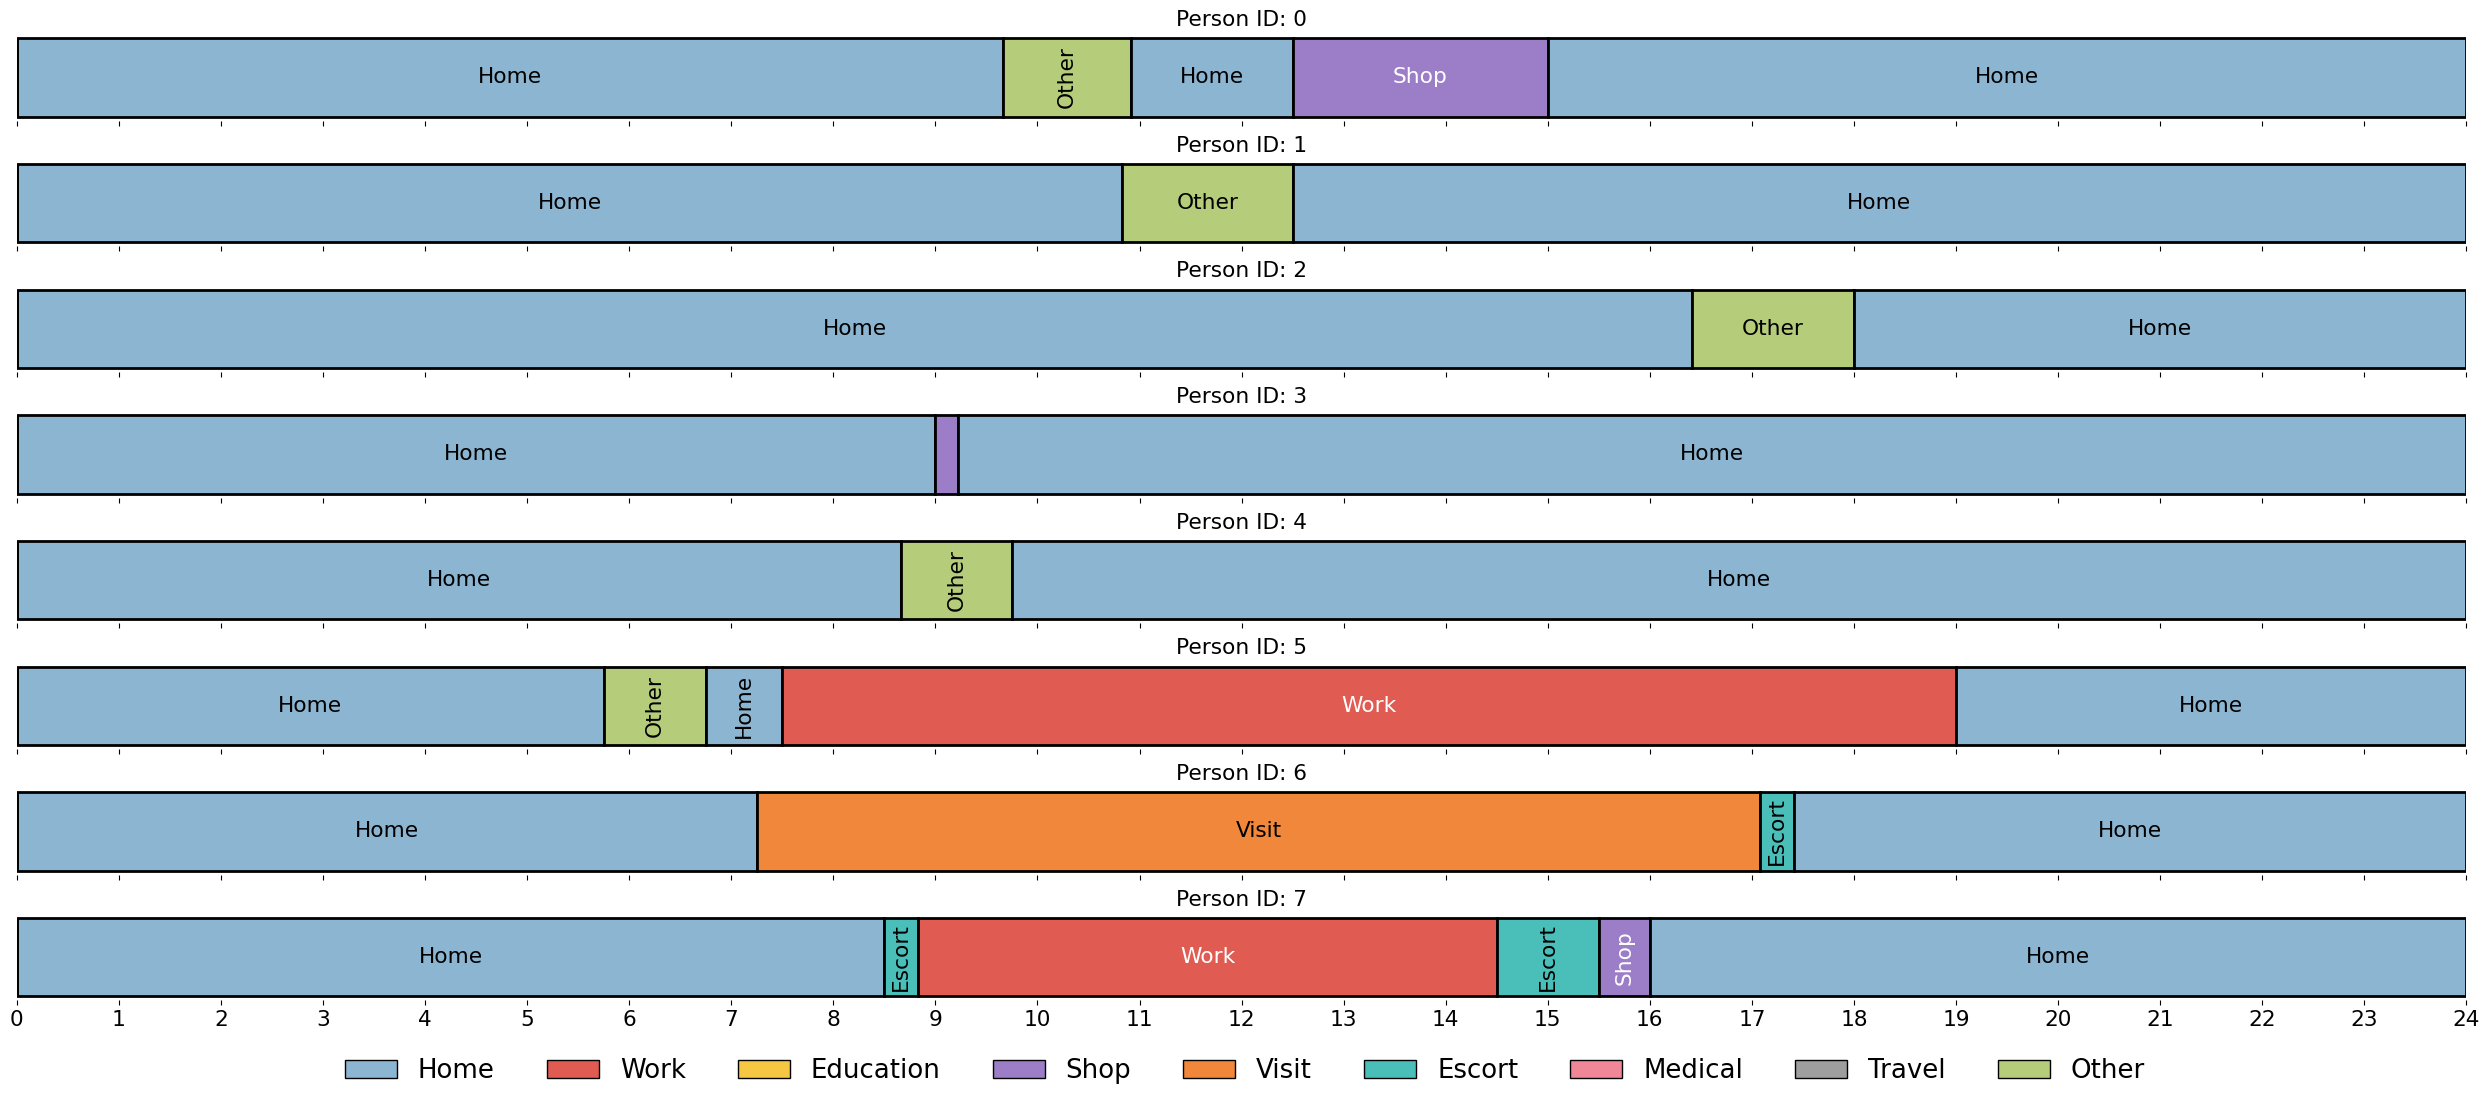

In [ ]:
# plot_schedules(target_schedules, cmap=cmap)

/tmp/ipykernel_41034/2729459132.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_41034/2729459132.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_41034/2729459132.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This beha

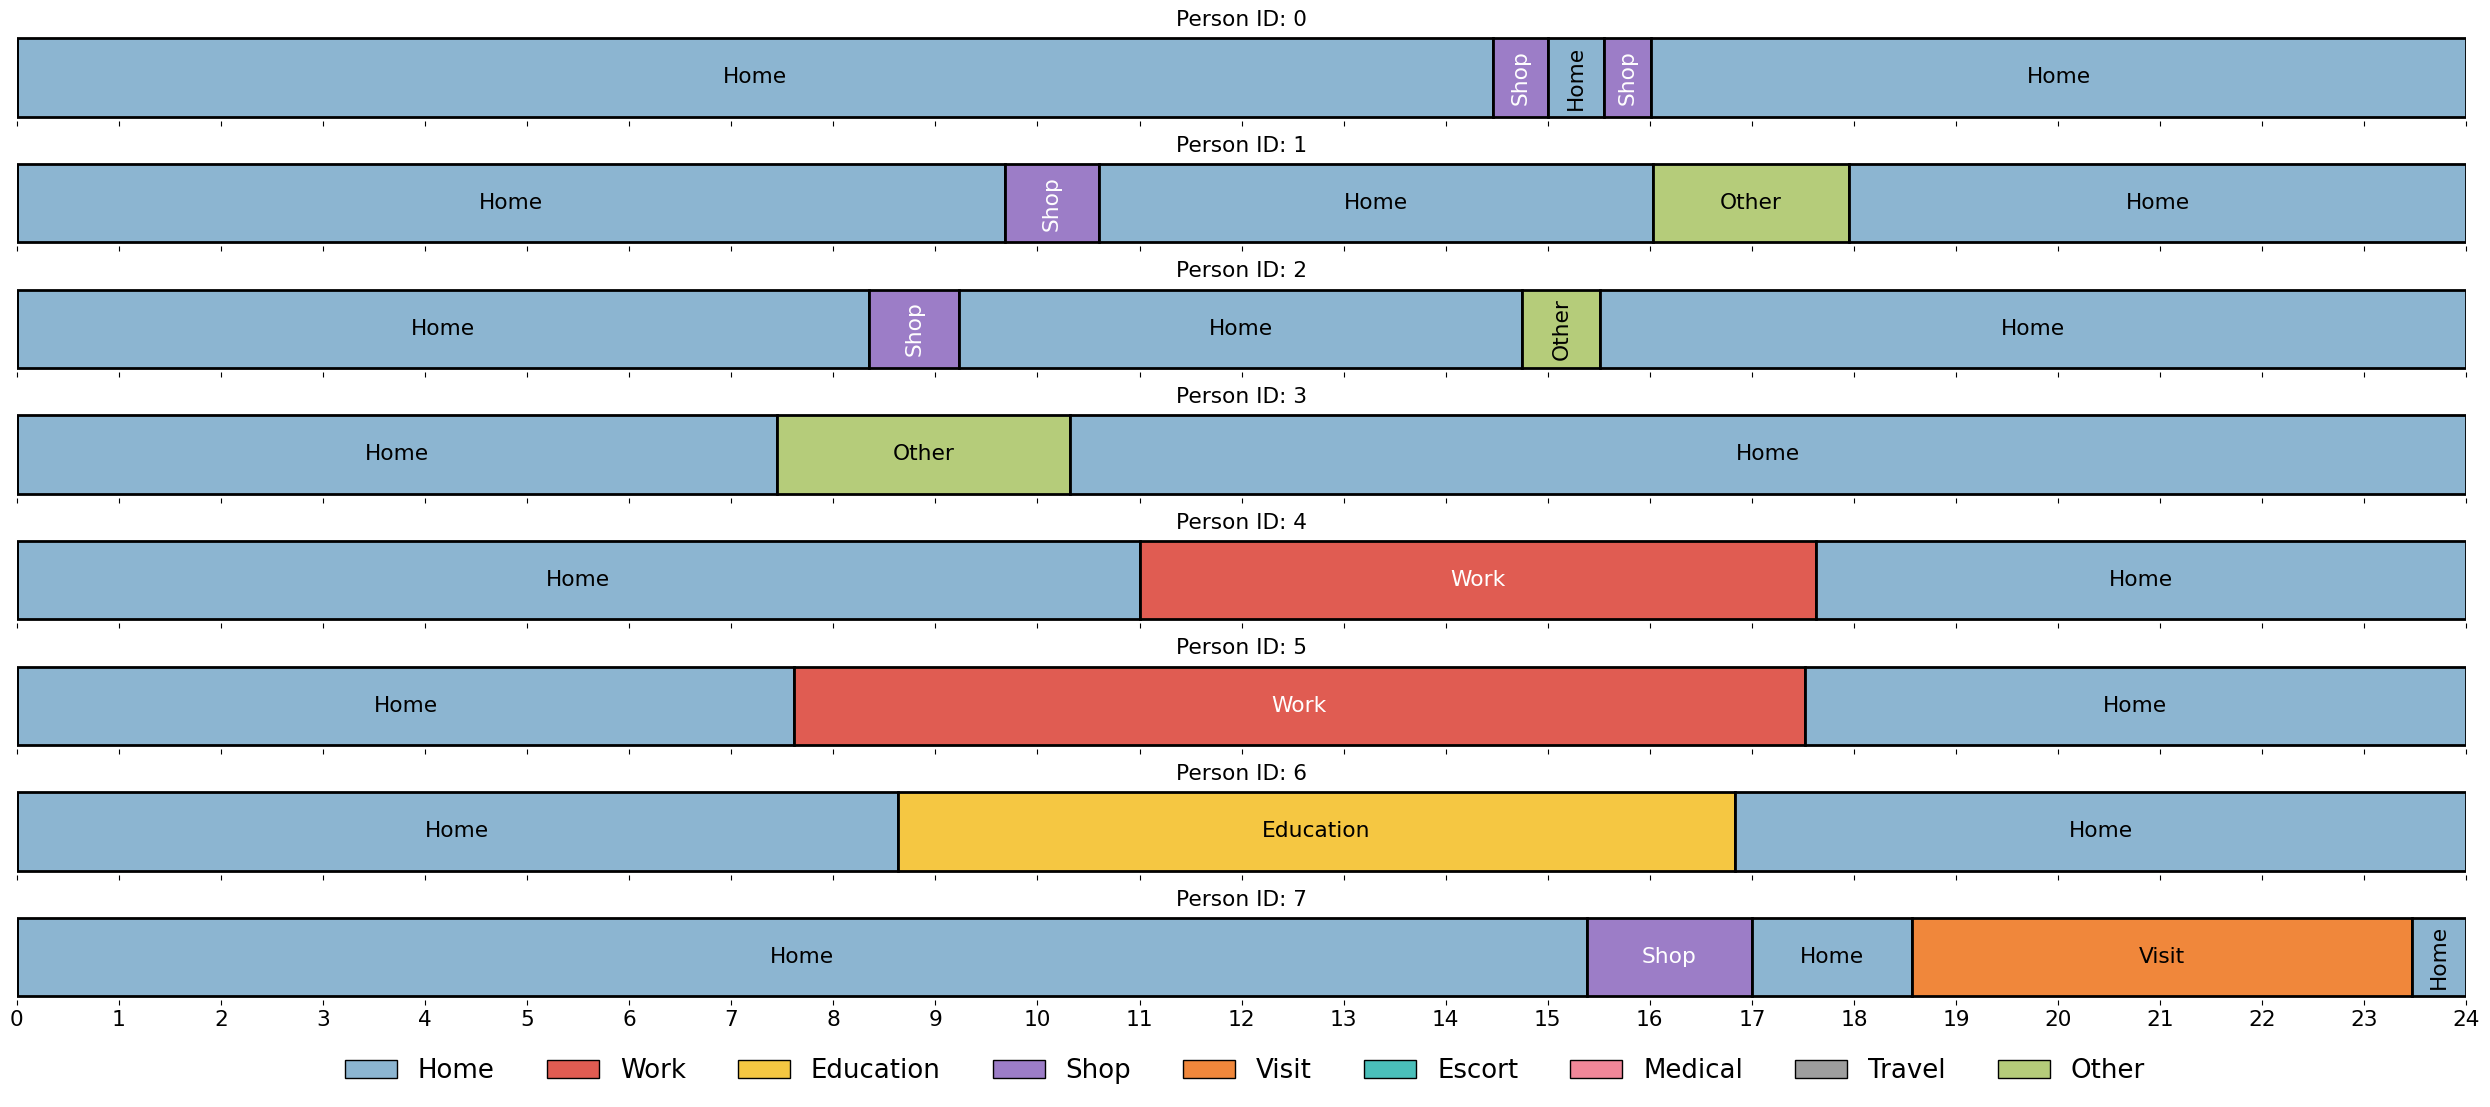

In [ ]:
# plot_schedules(schedules["ActVAE"], cmap=cmap)

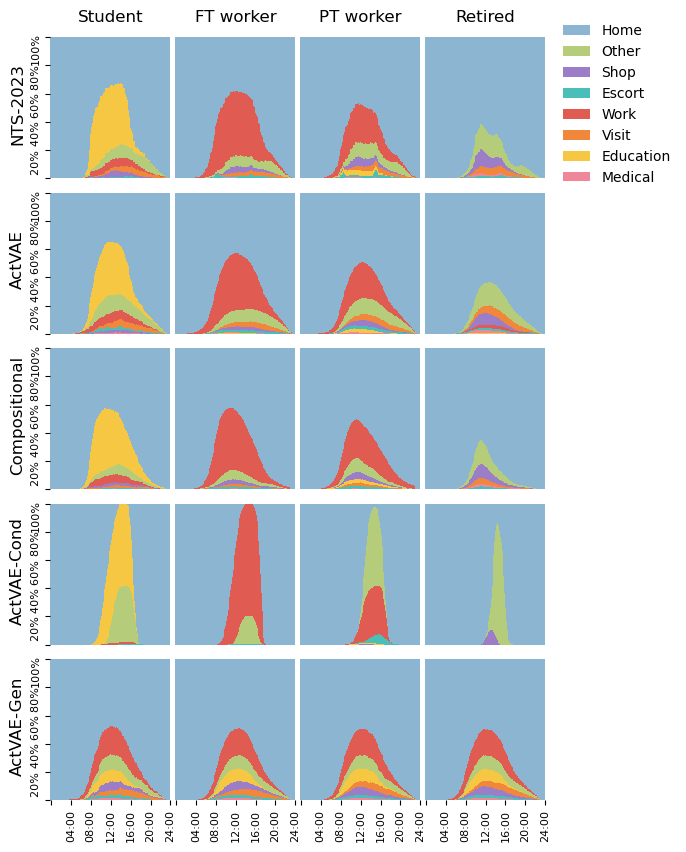

In [ ]:
plot_schedules = {
    "NTS-2023": target_schedules,
    "ActVAE": schedules["ActVAE"],
    "Compositional": schedules["Compositional"],
    "ActVAE-Cond": schedules["ActVAE-Cond"],
    "ActVAE-Gen": schedules["ActVAE-Gen"],
}
plot_attributes = {
    "NTS-2023": target_attributes,
    "ActVAE": attributes["ActVAE"],
    "Compositional": attributes["Compositional"],
    "ActVAE-Cond": attributes["ActVAE-Cond"],
    "ActVAE-Gen": attributes["ActVAE-Gen"],
}

act_order = target_schedules.act.value_counts().index.to_list()
class_map = {n: i for i, n in enumerate(act_order)}

FILTER = ["student", "ft-employed", "pt-employed", "retired"]
NAMES = ["Student", "FT worker", "PT worker", "Retired"]

h = len(plot_schedules)
w = len(FILTER)
fig, axes = plt.subplots(
    h, w + 1, figsize=(w * 2, h * 2), sharex=False, sharey=False
)

for i, (name, scheds) in enumerate(plot_schedules.items()):

    splits = split_on(scheds, plot_attributes[name], by="employment")

    for j, f in enumerate(FILTER):
        axes[0, j].set_title(NAMES[j], fontsize=12)
        selected = splits[f]
        ax = plot_agg_acts(
            "",
            selected,
            class_map=class_map,
            ax=axes[i, j],
            legend=False,
            color=cmaps,
        )
        ax.set_title(None)
        ax.set_ylabel(None)
        ax.set_xlabel(None)
        ax.set_yticks([])
        ax.set_xticks([])

        axes[-1, j].set_xticks(
            [i / 10 for i in [0, 240, 480, 720, 960, 1200, 1440]],
            labels=["", "04:00", "08:00", "12:00", "16:00", "20:00", "24:00"],
            rotation=90,
            fontsize=8,
        )

    axes[i, 0].set_ylabel(name, fontsize=12)
    axes[i, 0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    axes[i, 0].set_yticklabels(
        ["", "20% ", "40% ", "60% ", "80% ", "100%"], rotation=90, fontsize=8
    )

    axes[i, -1].axis("off")

elements = [Patch(facecolor=cmaps[act], label=act.title()) for act in act_order]
axes[0, -1].axis("off")
axes[0, -1].legend(handles=elements, loc="center left", frameon=False)

plt.subplots_adjust(wspace=0.04, hspace=0.05)

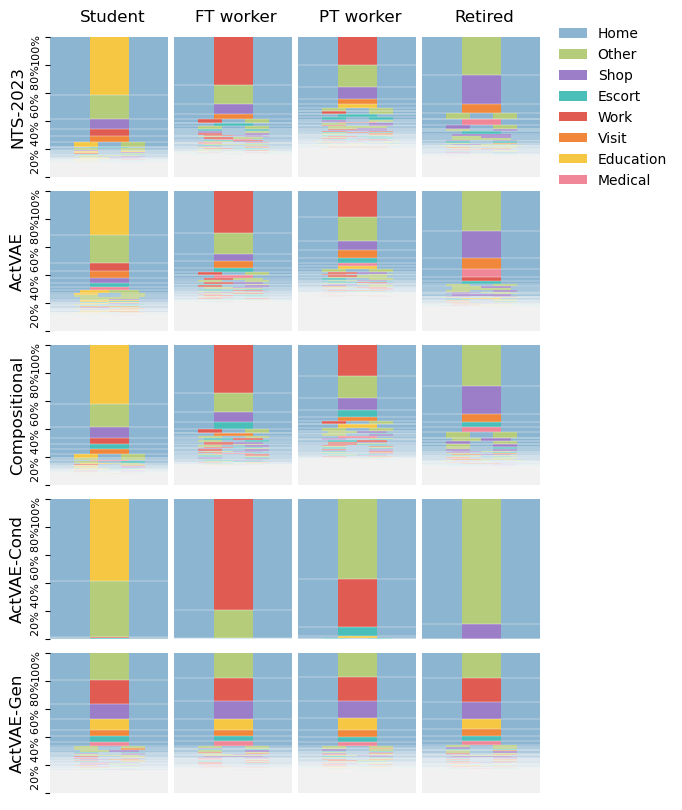

In [ ]:
h = len(plot_schedules)
w = len(FILTER)
fig, axes = plt.subplots(
    h, w + 1, figsize=(w * 2, h * 2), sharex=False, sharey=False
)

for i, (name, scheds) in enumerate(plot_schedules.items()):

    splits = split_on(scheds, plot_attributes[name], by="employment")

    for j, f in enumerate(FILTER):
        axes[0, j].set_title(NAMES[j], fontsize=12)
        selected = splits[f]
        ax = _probs_plot("", selected, cmap=cmaps, ax=axes[i, j])
        ax.set_title(None)
        ax.set_ylabel(None)
        ax.set_xlabel(None)
        ax.set_yticks([])
        ax.set_xticks([])

    axes[i, 0].set_ylabel(name, fontsize=12)
    axes[i, 0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    axes[i, 0].set_yticklabels(
        ["", "20% ", "40% ", "60% ", "80% ", "100%"], rotation=90, fontsize=8
    )

    axes[i, -1].axis("off")

elements = [Patch(facecolor=cmaps[act], label=act.title()) for act in act_order]
axes[0, -1].axis("off")
axes[0, -1].legend(handles=elements, loc="center left", frameon=False)


plt.subplots_adjust(wspace=0, hspace=0)

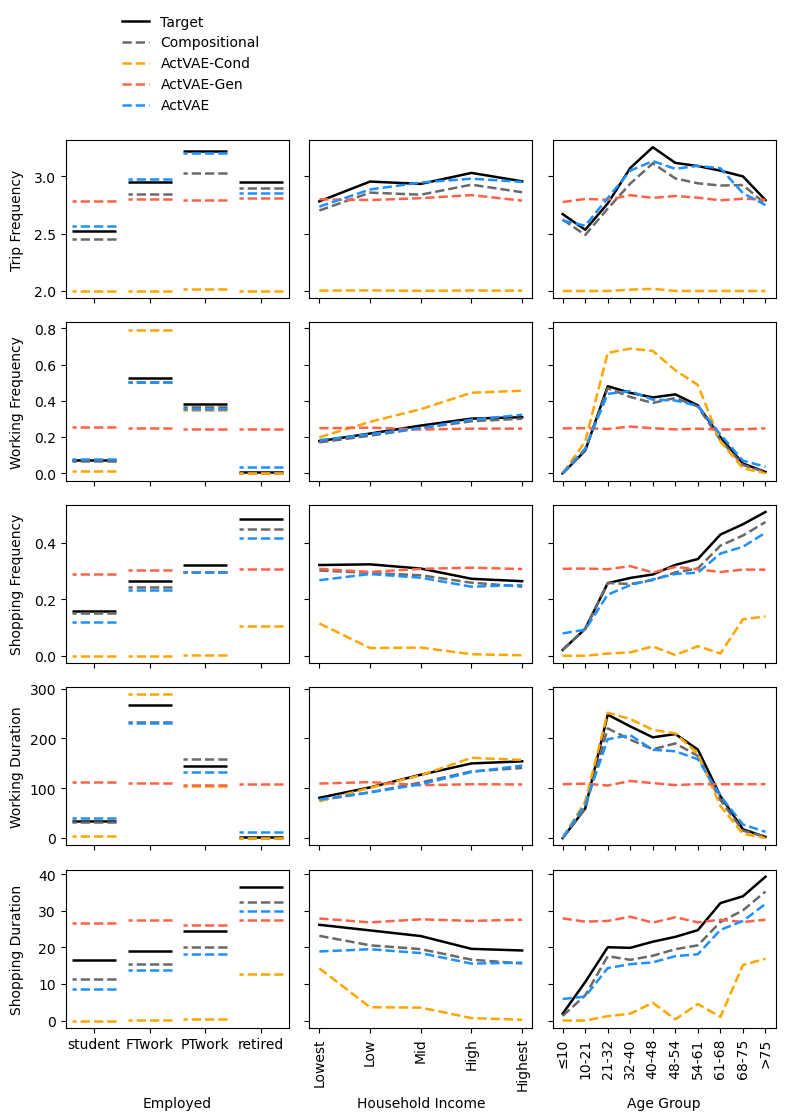

In [56]:
def duration(schedules, act="work"):
    if "duration" not in schedules.columns:
        durations = schedules.end - schedules.start
    else:
        durations = schedules.duration
    filtered = durations[schedules.act == act]
    n = schedules.pid.nunique()
    return filtered.sum(0) / n


def count_trips(schedules):
    n = schedules.pid.nunique()
    return (len(schedules) - n) / n


def count_acts(schedules, act="work"):
    n = schedules.pid.nunique()
    return len(schedules.loc[schedules.act == act]) / n


def plot_conditionals(
    schedules, attributes, target_schedules, target_attributes, figsize=(8, 10)
):
    WORK_STATUS = "employment"
    INCOME = "hh_income"
    AGE = "age"

    work_order = [
        # "retired",
        # "unemployed",
        "student",
        "ft-employed",
        "pt-employed",
        "retired",
    ]
    work_statuses = ["student", "FTwork", "PTwork", "retired"]

    age_order = [
        "≤10",
        "10-21",
        "21-32",
        "32-40",
        "40-48",
        "48-54",
        "54-61",
        "61-68",
        "68-75",
        ">75",
    ]
    ages = [
        "≤10",
        "10-21",
        "21-32",
        "32-40",
        "40-48",
        "48-54",
        "54-61",
        "61-68",
        "68-75",
        ">75",
    ]
    incomes = ["≤22316", "22316-32118", "32118-44107", "44107-68887", ">68887"]
    colours = [
        "black",
        "dimgray",
        "orange",
        "tomato",
        "dodgerblue",
        "grey",
        "black",
        "lightgrey",
        "pink",
        "green",
    ]
    styles = ["-", "--", "--", "--", "--", ":", ":", ":", ":", ":", ":"]
    LW = 1.8

    fig, axs = plt.subplots(5, 3, figsize=figsize, sharex="col", sharey="row")

    # ==============================
    # trips employment
    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[0][0]
    # change to bar plot
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Trip Frequency")
    ax.legend().remove()

    # ==============================
    # trips income
    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[0][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ==================================
    # trips age group
    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_trips(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = count_trips(split)

    df = pd.DataFrame(data)
    ax = axs[0][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # =================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[1][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Working Frequency")
    ax.legend().remove()

    # =================================
    # work income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[1][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = count_acts(split)

    df = pd.DataFrame(data)
    ax = axs[1][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # =================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[2][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.set_ylabel("Shopping Frequency")
    ax.legend().remove()

    # =================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[2][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = count_acts(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = count_acts(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[2][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # work employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[3][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )
    ax.legend().remove()
    ax.set_ylabel("Working Duration")

    # ====================================
    # work income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[3][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # work age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split)

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = duration(split)

    df = pd.DataFrame(data)
    ax = axs[3][2]
    df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()

    # ====================================
    # shop employment

    splits = split_on(target_schedules, target_attributes, by=WORK_STATUS)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=WORK_STATUS)
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[work_order]
    ax = axs[4][0]
    for n, col, s in zip(df.columns, colours, styles):
        ax.scatter(
            df.index,
            df[n],
            label=n,
            color=col,
            lw=LW,
            marker="_",
            s=1000,
            linestyle=s,
        )

    ax.legend().remove()
    ax.set_xlim(-0.5, 3.5)

    ax.set_ylabel("Shopping Duration")
    ax.set_xlabel("Employed")
    ax.set_xticks(list(range(len(work_order))), work_statuses, rotation=0)

    # ====================================
    # shop income

    splits = split_on(target_schedules, target_attributes, by=INCOME)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=INCOME)
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    df = df.loc[incomes]
    ax = axs[4][1]
    df.plot(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()
    ax.set_xlabel("Household Income")
    ax.set_xticks(
        [0, 1, 2, 3, 4],
        ["Lowest", "Low", "Mid", "High", "Highest"],
        rotation=90,
    )

    # ====================================
    # shop age group

    splits = split_on(target_schedules, target_attributes, by=AGE)
    data = {"Target": {}}
    for i, split in splits.items():
        data["Target"][i] = duration(split, act="shop")

    for n, scheds in schedules.items():
        data[n] = {}
        atts = attributes[n]
        splits = split_on(scheds, atts, by=AGE)
        for i, split in splits.items():
            data[n][i] = duration(split, act="shop")

    df = pd.DataFrame(data)
    ax = axs[4][2]
    df.loc[age_order].plot.line(ax=ax, color=colours, style=styles, lw=LW)
    ax.legend().remove()
    ax.set_xlabel("Age Group")
    ax.set_xticks(range(len(ages)), ages, rotation=90)

    # for ax in axs.flat:
    #     ax.grid(visible=True, which="major", axis="x", color="grey", linestyle="-")

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        frameon=False,
        fontsize=10,
        bbox_to_anchor=(0.25, 1),
    )

    fig.align_ylabels(axs[:, 0])
    fig.align_xlabels(axs[-1, :])

    fig.tight_layout()


plot_conditionals(schedules, attributes, target_schedules, target_attributes)

In [ ]:
# structure ablation
ablations = {
    "actvae": pd.read_csv(Path("../logs/TRB/cvae/domain_distances_subs.csv"))
    .set_index("domain")
    .drop("observed", axis=1)
    .mean(axis=1)
}

abs = ["aaaa", "cncn", "deep", "nana", "nnan", "no_weighting", "shallow"]

for p in abs:
    path = Path(f"../logs/TRB/ablation/{p}/domain_distances_subs.csv")
    ablations[p] = (
        pd.read_csv(path)
        .set_index("domain")
        .drop("observed", axis=1)
        .mean(axis=1)
    )
ablations = pd.DataFrame(ablations).T

print(
    ablations[
        ["participations", "transitions", "timing", "feasibility", "creativity"]
    ].to_latex(float_format="{:.3f}".format)
)
ablations

In [ ]:
diffs = ablations[
    ["participations", "transitions", "timing", "feasibility", "creativity"]
]
for a in abs:
    diffs.loc[a] = diffs.loc[a] - diffs.loc["actvae"]
print(
    diffs.T[
        ["actvae", "no_weighting", "cncn", "nana", "nnan", "aaaa"]
    ].to_latex(float_format="{:.3f}".format)
)

In [ ]:
structure_schedules = {
    "actvae": pd.read_csv(
        latest(Path("../logs/TRB/cvae/cvae_nrun1"))[1]
        / "synthetic_schedules.csv"
    )
}
structure_attributes = {
    "actvae": pd.read_csv(
        latest(Path("../logs/TRB/cvae/cvae_nrun1"))[1]
        / "synthetic_attributes.csv"
    )
}
for name in abs:
    structure_schedules[name] = pd.read_csv(
        latest(Path(f"../logs/TRB/ablation/{name}/{name}_nrun1"))[1]
        / "synthetic_schedules.csv"
    )
    structure_attributes[name] = pd.read_csv(
        latest(Path(f"../logs/TRB/ablation/{name}/{name}_nrun1"))[1]
        / "synthetic_attributes.csv"
    )

In [ ]:
plot_conditionals(
    structure_schedules,
    structure_attributes,
    target_schedules,
    target_attributes,
    figsize=(12, 15),
)

In [ ]:
splits = split_on(target_schedules, target_attributes)
fig = describe_transitions.sequence_prob_plot(
    target_schedules, splits, observed_title="All", cmap=cmaps, figsize=(9, 3.5)
)

In [ ]:
for k, scheds in structure_schedules.items():
    print(k)
    splits = split_on(scheds, structure_attributes[k])
    fig = describe_transitions.sequence_prob_plot(
        scheds, splits, observed_title="All", cmap=cmaps, figsize=(9, 3.5)
    )

In [ ]:
# Ageing Scenario
attributes = {
    2023: pd.read_csv(Path("../tmp/nomis_ages_2023.csv")),
    2030: pd.read_csv(Path("../tmp/nomis_ages_2030.csv")),
    2040: pd.read_csv(Path("../tmp/nomis_ages_2040.csv")),
    2050: pd.read_csv(Path("../tmp/nomis_ages_2050.csv")),
}
demographics = pd.DataFrame(
    {year: a.age_group.value_counts() for year, a in attributes.items()}
).loc[
    ["<5", "5-11", "11-16", "16-20", "20-30", "30-40", "40-50", "50-70", "70+"]
]
print(demographics.sum(axis=0))
demographics

In [ ]:
# add zero row at top, i.e:
#     0, 0, 0, 0, 0
new_row = pd.DataFrame({year: 0 for year in demographics.columns}, index=["0"])
demographics = pd.concat([new_row, demographics])
demographics

In [ ]:
scaled = demographics * 100 / 1000000

scaled["duration"] = [1, 5, 6, 5, 4, 10, 10, 10, 20, 20]
for year in [2023, 2030, 2040, 2050]:
    scaled[year] = scaled[year] / scaled.duration
scaled.duration = scaled.duration.cumsum() - 1

fig, ax = plt.subplots(figsize=(6, 3))

# Use a colorblind-friendly palette from matplotlib
colors = [
    "#0072B2",
    "#009E73",
    "#D55E00",
    "#CC79A7",
]  # blue, green, orange, purple
linestyles = ["-", "-.", "--", ":"]

for year, c, linestyle in zip([2023, 2030, 2040, 2050], colors, linestyles):
    ax.step(
        scaled.duration,
        scaled[year],
        label=str(year),
        color=c,
        linestyle=linestyle,
        linewidth=2,
    )
# for y in scaled.index:
#     ax.axhline(y, color="lightgrey", linestyle="--", linewidth=0.5, zorder=0)

ax.set_ylabel("Density (millions per year)")
ax.set_xlabel("Age Group")
ax.legend(scaled.columns, loc="lower center", frameon=False, title_fontsize=12)
# ax.set_xlim(0, 20)

In [ ]:
scaled

In [ ]:
aged_schedule_paths = {
    n[1:]: Path("../logs/TRB/cvae_nomis_scenario") / n / "version_1"
    for n in ["a2023", "a2030", "a2040", "a2050"]
}
age_schedules = {
    n: pd.read_csv(p / "synthetic_schedules.csv")
    for n, p in aged_schedule_paths.items()
}
age_attributes = {
    n: pd.read_csv(p / "synthetic_attributes.csv")
    for n, p in aged_schedule_paths.items()
}
age_target = age_schedules.pop("2023")
age_attributes_target = age_attributes.pop("2023")

In [ ]:
fig = frequency_plots(
    age_target,
    age_schedules,
    color=cmaps,
    figsize=(8, 3.5),
    observed_title="Target",
)
fig = sequence_prob_plot(
    age_target,
    age_schedules,
    cmap=cmaps,
    figsize=(8, 3.5),
    observed_title="2023",
)

In [ ]:
# for k, scheds in age_schedules.items():
#     splits = split_on(scheds, age_attributes[k], by="age_group")
#     fig = describe_transitions.sequence_prob_plot(
#         scheds, splits, observed_title="All", cmap=cmap, figsize=(16, 3.5)
#     )

In [ ]:
aged_scenario = Path(
    "../logs/TRB/cvae_nomis_scenario/label_descriptions_subs.csv"
)
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment", "cat"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations", "participation rate"),
    ["a2023", "a2030", "a2040", "a2050"],
]
aged_scenario = aged_scenario.reset_index()
aged_scenario = aged_scenario.loc[aged_scenario.segment == "education"].drop(
    "segment", axis=1
)
aged_scenario = aged_scenario.set_index("cat")
aged_scenario = aged_scenario.loc[
    ["<5", "5-11", "11-16", "16-20", "20-30", "30-40", "40-50", "50-70", "70+"]
]
# aged_scenario = aged_scenario.pivot(columns="cat")
aged_scenario

In [ ]:
aged_scenario = Path("../logs/TRB/cvae_nomis_scenario/descriptions.csv")
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations"), ["a2023", "a2030", "a2040", "a2050"]
]
aged_scenario = aged_scenario.drop("pair participation rate", axis=0)
aged_scenario

In [ ]:
aged_scenario = Path("../logs/TRB/cvae_nomis_scenario/descriptions.csv")
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations"), ["a2023", "a2030", "a2040", "a2050"]
]
# aged_scenario = aged_scenario.loc["participation rate"]
aged_scenario = aged_scenario.drop("pair participation rate", axis=0)
for c in ["a2030", "a2040", "a2050"]:
    aged_scenario[c] = aged_scenario[c].astype(float)
    aged_scenario[f"{c}"] = (
        100
        * (aged_scenario[c] - aged_scenario["a2023"])
        / aged_scenario["a2023"]
    )
aged_scenario = aged_scenario.sort_values(by="a2023", ascending=False)
print(
    aged_scenario.to_latex(
        float_format="{:.3f}".format, index=True, label="tab:aged_scenario"
    )
)
aged_scenario

In [ ]:
schedules = {
    year: pd.read_csv(
        latest(Path("../logs/TRB/cvae_ageing_scenario") / f"a{year}")[1]
        / "synthetic_schedules.csv"
    )
    for year in ["2023", "2033", "2043", "2053"]
}

base = schedules.pop("2023")

fig = joint_time_distributions_plot(
    base,
    schedules,
    figsize=(8, 6),
    observed_title="2023",
    cmaps={
        0: "Blues",
        1: "Oranges",
        2: "Greens",
        3: "Reds",
        4: "Purples",
        5: "Greys",
    },
)
fig = frequency_plots(
    base, schedules, color=cmaps, figsize=(8, 3.5), observed_title="2023"
)
fig = describe_transitions.sequence_prob_plot(
    base, schedules, observed_title="2023", cmap=cmaps, figsize=(8, 3.5)
)

In [ ]:
sample_scenario = Path(
    "../logs/TRB/cvae_sampled_scenario/domain_distances_subs.csv"
)
sample_scenario = (
    pd.read_csv(sample_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    sample_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["s200", "s100", "s50", "s25", "s12"],
    ].to_latex(float_format="{:.3f}".format)
)

In [ ]:
s200 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s200"))[1]
    / "synthetic_schedules.csv"
)
s100 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s100"))[1]
    / "synthetic_schedules.csv"
)

s50 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s50"))[1]
    / "synthetic_schedules.csv"
)
s25 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s25"))[1]
    / "synthetic_schedules.csv"
)
s12 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s12"))[1]
    / "synthetic_schedules.csv"
)
# s6 = pd.read_csv(
#     latest(Path("../logs/TRB/cvae_sampled_scenario/s6"))[1]
#     / "synthetic_schedules.csv"
# )

sampled_schedules = {
    "200k": s200,
    "100k": s100,
    "50k": s50,
    "25k": s25,
    "12.5k": s12,
}

fig = times_distributions_plot(
    target_schedules, sampled_schedules, observed_title="Target", figsize=(9, 5)
)
fig = frequency_plots(
    target_schedules,
    sampled_schedules,
    color=cmaps,
    figsize=(9, 3.5),
    observed_title="Target",
)
fig = describe_transitions.sequence_prob_plot(
    target_schedules,
    sampled_schedules,
    observed_title="Target",
    cmap=cmaps,
    figsize=(9, 3.5),
)

In [ ]:
# # labels scenario
label_scenario = Path("../logs/TRB/cvae_labels_scenario/domain_distances.csv")
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        ["participations", "transitions", "timing", "feasibility", "creativity"]
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario[["l1", "l2", "l4", "l8", "l16"]]

In [ ]:
label_scenario = Path(
    "../logs/TRB/cvae_labels_scenario/domain_distances_subs.csv"
)
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        ["participations", "transitions", "timing", "feasibility", "creativity"]
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario[["l1", "l2", "l4", "l8"]]

In [ ]:
label_scenario = Path(
    "../logs/TRB/cvae_labels_scenario/label_descriptions_subs.csv"
)
label_scenario = pd.read_csv(label_scenario)
label_scenario = label_scenario.loc[
    label_scenario.cat.isin(["employed", "unemployed"])
]
label_scenario = label_scenario.set_index(
    ["domain", "feature", "segment", "label", "cat"]
).drop("unit", axis=1)


def aggregate_label_scenario(label_scenario):
    agg = {}
    for c in ["observed", "l1", "l2", "l4", "l8"]:
        agg[c] = (
            label_scenario[c] * label_scenario[f"{c}__weight"]
        ).sum() / label_scenario[f"{c}__weight"].sum()
    return pd.Series(agg)


label_scenario.groupby(["domain", "cat"]).apply(aggregate_label_scenario)

In [ ]:
l1 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l1"))[1]
    / "synthetic_schedules.csv"
)

l2 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l2"))[1]
    / "synthetic_schedules.csv"
)
l4 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l4"))[1]
    / "synthetic_schedules.csv"
)
l8 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l8"))[1]
    / "synthetic_schedules.csv"
)
l16 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l16"))[1]
    / "synthetic_schedules.csv"
)

sampled_schedules = {"L=1": l1, "L=2": l2, "L=4": l4, "L=8": l8, "L=16": l16}

fig = times_distributions_plot(
    target_schedules, sampled_schedules, observed_title="Target", figsize=(9, 5)
)
fig = frequency_plots(
    target_schedules,
    sampled_schedules,
    color=cmaps,
    figsize=(9, 3.5),
    observed_title="Target",
)
fig = describe_transitions.sequence_prob_plot(
    target_schedules,
    sampled_schedules,
    observed_title="Target",
    cmap=cmaps,
    figsize=(9, 3.5),
)

In [ ]:
# transfer scenario
label_scenario = Path("../logs/TRB/cvae_foundation/domain_distances.csv")
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["unconditioned", "conditioned"],
    ].to_latex(float_format="{:.3f}".format)
)

label_scenario = Path("../logs/TRB/cvae_foundation/domain_distances_subs.csv")
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["unconditioned", "conditioned"],
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario

In [ ]:
for n in ["aggregate", "participations", "transitions", "timing"]:
    print(n)
    print(table.loc[n].to_latex(float_format="{:.3f}".format))
    print()

In [ ]:
def build_creativity_table(batch_paths):
    descriptions_combined = pd.DataFrame()
    distances_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = (
            pd.read_csv(path / "descriptions.csv")
            .set_index(["domain", "feature", "segment"])
            .loc["creativity"]
        )
        distances = (
            pd.read_csv(path / "distances.csv")
            .set_index(["domain", "feature", "segment"])
            .loc["creativity"]
        )

        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(["observed", "description", "mean", "std", "feature count"])
            - weights
        )

        descriptions_combined[name, "desc."] = descriptions[columns].mean(
            axis=1
        )

        distances_combined[name, "dist."] = distances[columns].mean(axis=1)

    descriptions_combined["Observed", ""] = descriptions["observed"]
    descriptions_combined["Description", ""] = descriptions["description"]

    print(descriptions_combined.columns)

    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    distances_combined["Observed", ""] = distances["observed"]
    distances_combined["Description", ""] = distances["distance"]

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order.pop(order.index(("Description", "")))
    order = [("Observed", "")] + order + [("Description", "")]
    descriptions_combined = descriptions_combined.loc[:, order]

    order = list(distances_combined.columns)
    order.pop(order.index(("Observed", "")))
    order.pop(order.index(("Description", "")))
    order = [("Observed", "")] + order + [("Description", "")]
    distances_combined = distances_combined.loc[:, order]

    return pd.concat((descriptions_combined, distances_combined), axis=0)


table = build_creativity_table(batch_paths)
table

In [ ]:
print(table.loc["sample quality"].to_latex(float_format="{:.3f}".format))
table.loc["sample quality"]

In [ ]:
table.loc["creativity"]

In [ ]:
print(table.to_latex(float_format="{:.3f}".format))

In [ ]:
for domain in [
    "creativity",
    "sample quality",
    "aggregate",
    "participations",
    "transitions",
    "timing",
]:
    print()
    print(domain)
    print()
    ss = table.loc[domain]
    for feature in set(ss.reset_index()["feature"]):
        print(feature)
        print()
        print(ss.loc[feature].to_latex(float_format="{:.3f}".format))

In [ ]:
def build_subs_description_tables(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(path / "descriptions_subs.csv").set_index(
            ["domain", "feature", "segment", "sub_pop"]
        )
        columns = set(descriptions.columns)
        columns = list(
            columns
            - set(["observed", "description", "mean", "std", "feature count"])
        )

        descriptions_combined[name] = descriptions[columns].mean(axis=1)

    descriptions_combined["Observed"] = descriptions["observed"]
    descriptions_combined["Description"] = descriptions["description"]

    descriptions_combined = (
        descriptions_combined.sort_values("Observed", ascending=False)
        .groupby(["domain", "feature", "sub_pop"])
        .head(100)
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index("Observed"))
    order = ["Observed"] + order

    index = [
        "creativity",
        "sample quality",
        "aggregate",
        "participations",
        "transitions",
        "timing",
    ]

    return descriptions_combined.loc[index, order]


table = build_subs_description_tables(batch_paths)
table

In [ ]:
table.loc[
    "participations",
    "participation rate",
    "work0",
    ["work_status=student", "work_status=employed"],
]

In [ ]:
table.loc[
    "participations",
    "participation rate",
    "education0",
    ["work_status=student", "work_status=employed"],
]